# imports

In [1]:

import sionna.rt as rt

# Other imports
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np
import tensorflow as tf
from metrics import compute_kpis, plot_kpis
from sim import simulate, build_rx_path

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")
print(tf.config.list_physical_devices('GPU'))

I0000 00:00:1781503976.967272   10590 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781503977.003680   10590 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781503978.115846   10590 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Mitsuba variant: cuda_ad_mono_polarized
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Params

In [ ]:
preview = False;
render = False;
generate_metrics = True;
beamforming_on = True;
precoder_alpha = 0.0;   # RZF/MMSE regularization: 0 = pure ZF, larger = more robust to CSI error (-> MRT as alpha grows)
csi_error_std = 0.0;    # stddev of simulated per-entry CSI estimation error (0 = perfect CSI)

#single tone or multi tone signal
#filtering and bpsk symbols

# create scene

In [3]:
scene = load_scene(rt.scene.simple_street_canyon, merge_shapes=False)
scene.frequency = 28e9

# create transmitter and add it to the scene
scene.tx_array = PlanarArray(num_rows=8, num_cols=8, pattern="tr38901", polarization="V") #document these
scene.rx_array = scene.tx_array



In [4]:

# -----------------------------
# DEFINE CAMERAS
# -----------------------------
cameras = {
    #"cam1": Camera(position=[120, 5, 50], look_at=[15, 0, 0]),
    #,
    "cam2": Camera(position=[0, 0, 270], look_at=[0, 0, 0])
}

#------------------------------
# DEFINE DRONES
# -----------------------------
uas1 = rt.Receiver(name="uas_1", position=[-75.0, -5.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas1.color=[1,1,0]
scene.add(uas1)
uas2 = rt.Receiver(name="uas_2", position=[-75.0, 0.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas2.color=[1,0,1]
scene.add(uas2)
uas3 = rt.Receiver(name="uas_3", position=[-75.0, 5.0, 20.0], orientation=[0.0, 0.0, 0.0])
uas3.color=[0,1,1]
scene.add(uas3)

# create transmitter and add it to the scene
tx = rt.Transmitter(name="tx_1", position=[0.0, 0.0, 1.5])
scene.add(tx)

# -----------------------------
# CONFIG
# -----------------------------
num_drones = 3
num_steps = 100  # increased resolution
dt = 0.05        # smaller timestep

# -----------------------------
# BUILD RX PATHS [N, T, 3]
# -----------------------------
start_points = tf.constant([
    [-75, -5, 20],  # yellow
    [-75,  0, 20],  # cyan
    [-75,  5, 20]   # pink
], dtype=tf.float32)

base_velocities = tf.constant([
    [[0, -50,  0], [50, 0, 0], [50, 0, 0], [50, 0, 0], [00, 50, 0]],
    [[50, 0,  0], [0, 50, 0], [50, 0, 20], [0, -50, 0], [50, 0, 0]],
    [[25, 25, 15], [50, -50, 20], [0, 50, 0], [50, -50, -20], [0, 50, 0]]
], dtype=tf.float32)  # Shape: [N, _base_steps, 3]

rx_path = build_rx_path(start_points, base_velocities, num_steps, dt, on_mismatch="error")

I0000 00:00:1781503978.533110   10590 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3965 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
"""# 30 drones of randomness
# -----------------------------
# CONFIG
# -----------------------------
num_drones = 30
num_steps = 5
dt = 1.0



# -----------------------------
# BUILD TRANSMITTER PATHS [N, T, 3]
# -----------------------------
start_points = tf.constant([
    [-80, -50, 20],
    [-75, -40, 25],
    [-70, -30, 15],
    [-65, -20, 30],
    [-60, -10, 10],
    [-55,   0, 20],
    [-50,  10, 25],
    [-45,  20, 15],
    [-40,  30, 35],
    [-35,  40, 20],
    [-30,  50, 10],
    [-20, -50, 25],
    [-10, -40, 15],
    [  0, -30, 30],
    [ 10, -20, 20],
    [ 20, -10, 10],
    [ 30,   0, 25],
    [ 40,  10, 15],
    [ 50,  20, 35],
    [ 60,  30, 20],
    [ 70,  40, 10],
    [ 80,  50, 25],
    [-85,  55, 15],
    [-60,  55, 30],
    [-35, -55, 20],
    [ -5,  55, 10],
    [ 25, -55, 25],
    [ 55,  55, 15],
    [ 85, -55, 35],
    [  0,   0, 20]
], dtype=tf.float32)

# -----------------------------
# DEFINE DRONES
# -----------------------------
drone_colors = [
    [1,0,0], [0,1,0], [0,0,1], [1,1,0], [1,0,1],
    [0,1,1], [1,0.5,0], [0.5,0,1], [0,0.5,1], [0.5,1,0],
    [1,0,0.5], [0,1,0.5], [0.7,0.7,0.7], [1,0.7,0], [0.7,1,0],
    [0,0.7,1], [1,0,0.7], [0.7,0,1], [0,1,0.7], [0.5,0.5,1],
    [1,0.5,0.5], [0.5,1,0.5], [0.5,0.5,0.5], [1,1,0.5], [1,0.5,1],
    [0.5,1,1], [0.8,0.2,0.2], [0.2,0.8,0.2], [0.2,0.2,0.8], [1,1,1]
]

uas_list = []

for i in range(30):
    uas = rt.Transmitter(
        name=f"uas_{i+1}",
        position=start_points[i].numpy().tolist(),
        orientation=[0.0, 0.0, 0.0]
    )
    uas.color = drone_colors[i]
    scene.add(uas)
    uas_list.append(uas)

# create receiver and add it to the scene
rx = rt.Receiver(name="rx_1", position=[0.0, 0.0, 1.5])
scene.add(rx)

velocities = tf.constant([
    [[ 4,  2,  1], [ 5, -3,  0], [ 3,  4, -1], [ 6,  0,  2], [ 4, -2,  1]],
    [[ 5,  1, -1], [ 4,  3,  2], [ 3, -4,  0], [ 5,  2,  1], [ 4, -3, -1]],
    [[ 3,  5,  1], [ 4, -2,  2], [ 5,  1, -1], [ 3,  4,  0], [ 4, -3,  1]],
    [[ 6, -1,  0], [ 4,  3,  1], [ 5, -2,  2], [ 3,  5, -1], [ 4, -2,  0]],
    [[ 4,  4,  1], [ 3, -5,  0], [ 5,  2,  2], [ 4,  3, -1], [ 3, -4,  1]],
    [[ 5, -2,  1], [ 4,  4, -1], [ 3, -3,  2], [ 6,  1,  0], [ 4,  2,  1]],
    [[ 3,  4,  2], [ 5, -1, -1], [ 4,  3,  0], [ 3, -5,  1], [ 5,  2,  2]],
    [[ 4, -3,  1], [ 3,  5,  0], [ 6, -1,  2], [ 4,  2, -1], [ 3, -4,  1]],
    [[ 5,  2, -1], [ 4, -3,  1], [ 3,  5,  2], [ 5,  1,  0], [ 4, -2, -1]],
    [[ 3, -5,  0], [ 5,  2,  1], [ 4,  3, -1], [ 6, -1,  2], [ 3,  4,  0]],
    [[ 4,  3,  2], [ 3, -4,  0], [ 5,  1, -1], [ 4,  4,  1], [ 3, -3,  2]],
    [[ 5, -1,  0], [ 4,  3,  2], [ 3, -5,  1], [ 5,  2, -1], [ 4, -2,  0]],
    [[ 3,  4, -1], [ 5, -2,  1], [ 4,  3,  0], [ 3, -4,  2], [ 5,  1, -1]],
    [[ 4, -3,  2], [ 3,  5,  0], [ 5, -1,  1], [ 4,  2, -1], [ 3, -5,  2]],
    [[ 5,  2,  1], [ 4, -4, -1], [ 3,  3,  2], [ 5,  1,  0], [ 4, -2,  1]],
    [[ 3, -4,  0], [ 5,  2,  1], [ 4,  3, -1], [ 3, -5,  2], [ 5,  1,  0]],
    [[ 4,  3,  1], [ 3, -4,  2], [ 5,  2, -1], [ 4,  4,  0], [ 3, -3,  1]],
    [[ 5, -2,  0], [ 4,  3,  1], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  0]],
    [[ 3,  5,  1], [ 5, -1, -1], [ 4,  2,  2], [ 3, -4,  0], [ 5,  3,  1]],
    [[ 4, -3,  2], [ 3,  4, -1], [ 5,  1,  0], [ 4, -5,  1], [ 3,  2,  2]],
    [[ 5,  2, -1], [ 4, -4,  1], [ 3,  5,  0], [ 5,  1,  2], [ 4, -2, -1]],
    [[ 3, -5,  1], [ 5,  2,  0], [ 4,  3, -1], [ 3, -4,  2], [ 5,  1,  1]],
    [[ 4,  3,  0], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  1], [ 3, -4,  0]],
    [[ 5, -2,  1], [ 4,  4, -1], [ 3, -3,  2], [ 5,  1,  0], [ 4,  2,  1]],
    [[ 3,  5, -1], [ 5, -1,  1], [ 4,  2,  0], [ 3, -4,  2], [ 5,  3, -1]],
    [[ 4, -3,  2], [ 3,  4,  0], [ 5,  1, -1], [ 4, -5,  1], [ 3,  2,  2]],
    [[ 5,  2,  1], [ 4, -4, -1], [ 3,  5,  0], [ 5,  1,  2], [ 4, -2,  1]],
    [[ 3, -5,  0], [ 5,  2,  1], [ 4,  3, -1], [ 3, -4,  2], [ 5,  1,  0]],
    [[ 4,  3,  2], [ 3, -4,  0], [ 5,  1, -1], [ 4,  4,  1], [ 3, -3,  2]],
    [[ 5, -2,  1], [ 4,  3,  0], [ 3, -5,  2], [ 5,  1, -1], [ 4,  2,  1]]
], dtype=tf.float32)

# -----------------------------
# DEFINE CAMERAS
# -----------------------------
cameras = {
    "cam1": Camera(position=[120, 5, 50], look_at=[15, 0, 0]),
    "cam2": Camera(position=[0, 0, 220], look_at=[0, 0, 0])
}

displacements = tf.cumsum(velocities * dt, axis=1, exclusive=False)
transmitter_path = tf.concat([start_points[:, tf.newaxis, :],
                               start_points[:, tf.newaxis, :] + displacements], axis=1)
scene.preview()"""

'# 30 drones of randomness\n# -----------------------------\n# CONFIG\n# -----------------------------\nnum_drones = 30\nnum_steps = 5\ndt = 1.0\n\n\n\n# -----------------------------\n# BUILD TRANSMITTER PATHS [N, T, 3]\n# -----------------------------\nstart_points = tf.constant([\n    [-80, -50, 20],\n    [-75, -40, 25],\n    [-70, -30, 15],\n    [-65, -20, 30],\n    [-60, -10, 10],\n    [-55,   0, 20],\n    [-50,  10, 25],\n    [-45,  20, 15],\n    [-40,  30, 35],\n    [-35,  40, 20],\n    [-30,  50, 10],\n    [-20, -50, 25],\n    [-10, -40, 15],\n    [  0, -30, 30],\n    [ 10, -20, 20],\n    [ 20, -10, 10],\n    [ 30,   0, 25],\n    [ 40,  10, 15],\n    [ 50,  20, 35],\n    [ 60,  30, 20],\n    [ 70,  40, 10],\n    [ 80,  50, 25],\n    [-85,  55, 15],\n    [-60,  55, 30],\n    [-35, -55, 20],\n    [ -5,  55, 10],\n    [ 25, -55, 25],\n    [ 55,  55, 15],\n    [ 85, -55, 35],\n    [  0,   0, 20]\n], dtype=tf.float32)\n\n# -----------------------------\n# DEFINE DRONES\n# ----------

In [6]:

# -----------------------------
# RUN SIMULATION
# -----------------------------
kpi_log = simulate(
    rx_path=rx_path,
    cameras=cameras,
    scene=scene,
    generate_metrics=generate_metrics,
    render=render,
    beamforming_on=beamforming_on,
    precoder_alpha=precoder_alpha,
    csi_error_std=csi_error_std
)

Step 0: {'uas_1': {'snr_db': np.float32(19.748152), 'ber': 2.9987787136551085e-43, 'throughput_mbps': 657.54, 'coverage_fraction': 1.0, 'position': [[-75.0], [-5.0], [20.0]]}, 'uas_2': {'snr_db': np.float32(19.999626), 'ber': 1.401298464324817e-45, 'throughput_mbps': 665.81, 'coverage_fraction': 1.0, 'position': [[-75.0], [0.0], [20.0]]}, 'uas_3': {'snr_db': np.float32(19.76111), 'ber': 2.2701035122062037e-43, 'throughput_mbps': 657.97, 'coverage_fraction': 1.0, 'position': [[-75.0], [5.0], [20.0]]}}
Step 1: {'uas_1': {'snr_db': np.float32(18.504414), 'ber': 5.5615679329035175e-33, 'throughput_mbps': 616.72, 'coverage_fraction': 1.0, 'position': [[-75.0], [-7.5], [20.0]]}, 'uas_2': {'snr_db': np.float32(14.340546), 'ber': 8.450505513445464e-14, 'throughput_mbps': 481.6, 'coverage_fraction': 1.0, 'position': [[-72.5], [0.0], [20.0]]}, 'uas_3': {'snr_db': np.float32(7.199336), 'ber': 0.0005986375035718083, 'throughput_mbps': 264.32, 'coverage_fraction': 1.0, 'position': [[-73.75], [6.25]

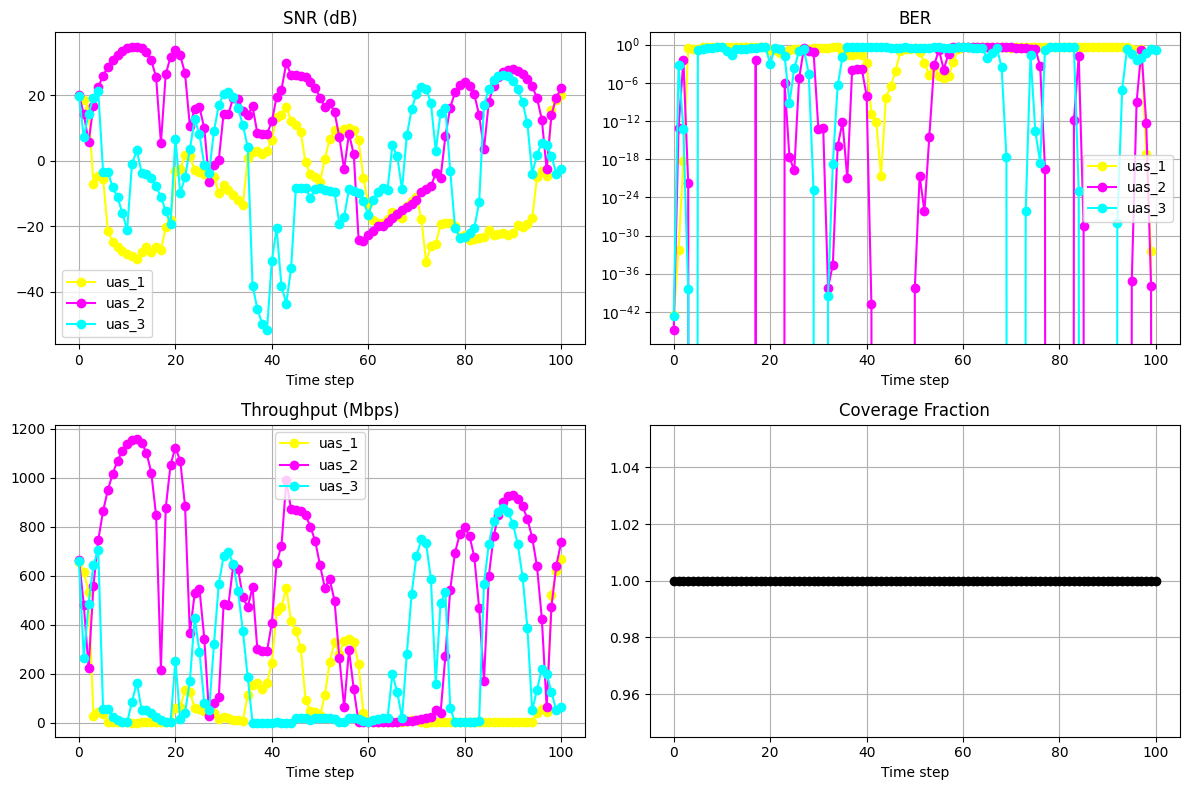

In [7]:
# -----------------------------
# PLOT KPIs
# -----------------------------
plot_kpis(kpi_log, scene)